# **04. Model Tuning**

In [46]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sidetable
import sklearn
import feature_engine
import scipy
from scipy import stats
from pathlib import Path
import pickle
import joblib
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, FunctionTransformer, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.metrics import make_scorer

%matplotlib inline
sns.set_style('darkgrid')


In [23]:
# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [24]:
# define file path for processed data
parent_path = Path.cwd().parent
file_path = parent_path.joinpath("models", "processed.pkl")


In [25]:
# Load the processed data from the previous step
print(f"Loading processed data...")
with open(file_path, "rb") as f:
    processed_data = pickle.load(f)

Loading processed data...


In [26]:
processed_data.keys()


dict_keys(['X_train', 'y_train', 'X_test', 'test_id', 'numeric_features', 'ordinal_features', 'categorical_features', 'boolean_features', 'year_features'])

In [27]:
# Extract features and target variable
X_train = processed_data["X_train"]
y_train = processed_data["y_train"]
X_test = processed_data["X_test"]
numeric_feat = processed_data["numeric_features"]
ordinal_feat = processed_data["ordinal_features"]
categorical_feat = processed_data["categorical_features"]
boolean_feat = processed_data["boolean_features"]
year_feat = processed_data["year_features"]
test_id = processed_data['test_id']


In [28]:
print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")


Training data shape: (1459, 23)
Test data shape: (1457, 23)


In [40]:
# Load the best model info from baseline
best_file_path = parent_path.joinpath('models', 'best_model.pkl')
try:
    print("Loading best model from baseline step...")
    with open(best_file_path, 'rb') as f:
        best_baseline_model = joblib.load(f)

    # use the model class from baseline to determine which model to tune
    if hasattr(best_baseline_model, 'named_steps'):
        model_class = best_baseline_model.named_steps['model'].__class__.__name__
    else:
        model_class = best_baseline_model.__class__.__name__
    print(f"Best model from baseline: {model_class}")
    
except:
    print("No best model file found from baseline. Using Ridge and Lasso as default.")
    model_class = 'Ridge'  # Default to Ridge if no best model found

Loading best model from baseline step...
Best model from baseline: ElasticNet


## **1. Setting up Preprocessing Pipeline**

In [45]:
print("\n=== SETTING UP PREPROCESSING PIPELINE ===")

# For numeric features: impute and scale
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# For categorical features: impute and one-hot encoding
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy='most_frequent')),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# For boolean features: convert into integer
boolean_transformer = Pipeline(steps=[
    ("bool", OrdinalEncoder(dtype=int))
])

# For year and ordinal features: use them as raw
year_transformer = Pipeline(steps=[
    ("passthrough", "passthrough")
])

ordinal_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# Combining processing steps
transformers = [("numeric", numeric_transformer, numeric_feat),
                ("boolean", boolean_transformer, boolean_feat),
                ("ordinal", ordinal_transformer, ordinal_feat),
                ("year", year_transformer, year_feat)

]

# Add categorical transformer if there is categorical feature:
if len(categorical_feat) > 0:
    transformers.append(("cat", categorical_transformer, categorical_feat))

preprocessor = ColumnTransformer(transformers=transformers)




=== SETTING UP PREPROCESSING PIPELINE ===


## **2. Hyperparameter Tuning for ElasticNet Regression**

In [48]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, KFold
print("\n=== HYPERPARAMETER TUNING ===")

# store tuning results in dictionary
tuning_results = {}

# Elasticnet Regression
if model_class in ['ElasticNet', 'LinearRegression']:
    print("\n1. Detailed ElasticNet Tuning")
    
    elasticnet_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', ElasticNet(max_iter=10000))
    ])
    elasticnet_param_grid = {
        'model__alpha': np.logspace(-4, 0, 10),
        'model__l1_ratio': np.linspace(0.1, 0.9, 9)
    }
    
    elasticnet_grid = GridSearchCV(
        elasticnet_pipeline,
        elasticnet_param_grid,
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        verbose=1
    )
    
    elasticnet_grid.fit(X_train, y_train)
    
    print(f"Best ElasticNet alpha: {elasticnet_grid.best_params_['model__alpha']:.6f}")
    print(f"Best ElasticNet l1_ratio: {elasticnet_grid.best_params_['model__l1_ratio']:.2f}")
    print(f"Best ElasticNet CV RMSE: ${-elasticnet_grid.best_score_:.2f}")
    
    tuning_results['ElasticNet'] = {
        'best_params': elasticnet_grid.best_params_,
        'cv_rmse': -elasticnet_grid.best_score_,
        'model': elasticnet_grid.best_estimator_
    }

# Ridge Regression Tuning
if model_class in ["Ridge", "LinearRegression"]:
    print("\n2. Detailed Ridge Regression Tuning")
    
    ridge_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', Ridge(max_iter=10000))
    ])
    
    ridge_param_grid = {'model__alpha': np.logspace(-2, 3, 30)}
    
    ridge_grid = GridSearchCV(
        ridge_pipeline,
        ridge_param_grid,
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        verbose=1
    )
    
    ridge_grid.fit(X_train, y_train)
    
    print(f"Best Ridge alpha: {ridge_grid.best_params_['model__alpha']:.4f}")
    print(f"Best Ridge CV RMSE: ${-ridge_grid.best_score_:.2f}")
    
    tuning_results['Ridge'] = {
        'best_params': ridge_grid.best_params_,
        'cv_rmse': -ridge_grid.best_score_,
        'model': ridge_grid.best_estimator_
    }

# Lasso Regression Tuning( if applicable)
if model_class == "Lasso":
    print("\n3. Detailed Lasso Regression Tuning")
    
    lasso_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', Lasso(max_iter=10000))
    ])
    
    lasso_param_grid = {'model__alpha': np.logspace(-4, 0, 100)}
    
    lasso_grid = GridSearchCV(
        lasso_pipeline,
        lasso_param_grid,
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        verbose=1
    )
    
    lasso_grid.fit(X_train, y_train)
    
    print(f"Best Lasso alpha: {lasso_grid.best_params_['model__alpha']:.6f}")
    print(f"Best Lasso CV RMSE: ${-lasso_grid.best_score_:.2f}")
    
    tuning_results['Lasso'] = {
        'best_params': lasso_grid.best_params_,
        'cv_rmse': -lasso_grid.best_score_,
        'model': lasso_grid.best_estimator_
    }


=== HYPERPARAMETER TUNING ===

1. Detailed ElasticNet Tuning
Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best ElasticNet alpha: 0.016681
Best ElasticNet l1_ratio: 0.90
Best ElasticNet CV RMSE: $33623.15


## **3. Compared Tuned Models**


=== COMPARING TUNED MODELS ===


,model,cv_rmse,parameters
0,ElasticNet,33623.146762,"{'model__alpha': 0.016681005372000592, 'model_..."


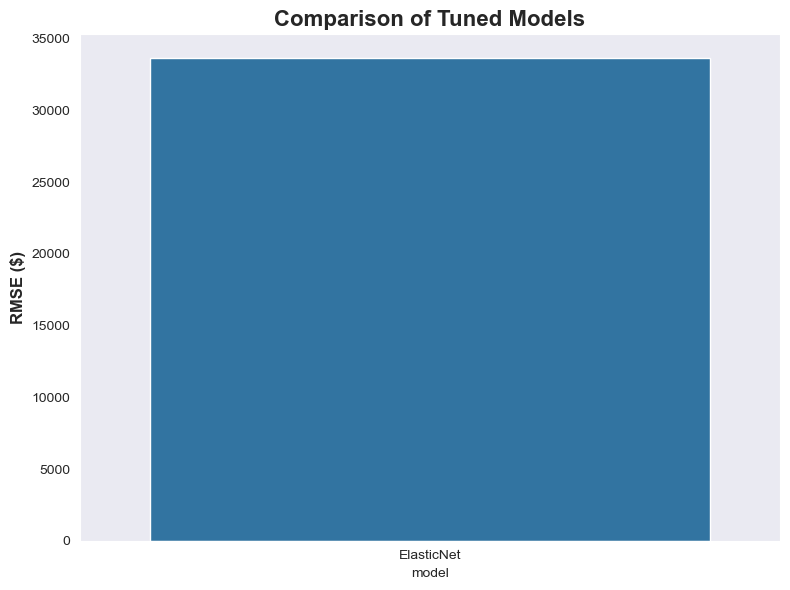

In [58]:
print("\n=== COMPARING TUNED MODELS ===")

# Create comparison DataFrame
tuned_df = pd.DataFrame({
    'model': list(tuning_results.keys()),
    'cv_rmse': [tuning_results[t]['cv_rmse'] for t in tuning_results],
    'parameters': [str(tuning_results[t]['best_params']) for t in tuning_results]
})

# Sort by CV RMSE
tuned_df = tuned_df.sort_values('cv_rmse')
display(tuned_df)

# Visualize results
plt.figure(figsize=(8, 6))
sns.barplot(x='model', y='cv_rmse', data=tuned_df)
plt.title('Comparison of Tuned Models', fontsize=16, fontweight='bold')
plt.ylabel('RMSE ($)', fontsize=12, fontweight='bold')
plt.grid(axis='y')

plt.tight_layout()
plt.show()

## **4. Selecting Final Model and Saving**

In [61]:
tuned_df

,model,cv_rmse,parameters
0,ElasticNet,33623.146762,"{'model__alpha': 0.016681005372000592, 'model_..."


In [78]:
best_model_name = tuned_df.iloc[0]['model']
best_params = tuning_results[best_model_name]['best_params']
best_rmse = tuning_results[best_model_name]['cv_rmse']
best_model = tuning_results[best_model_name]['model']

print(f"\n=== BEST MODEL ===")
print(f"Model: {best_model_name}")
print(f"Parameters: {best_params}")
print(f"CV RMSE: ${best_rmse:.2f}")

try:
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    prev_scores = cross_val_score(best_baseline_model, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')
    prev_rmse = -prev_scores.mean()
    
    improvement = prev_rmse - best_rmse
    percent_improvement = (improvement / prev_rmse) * 100
    
    print(f"Baseline RMSE: ${prev_rmse:.2f}")
    print(f"Tuned RMSE: ${best_rmse:.2f}")
    print(f"Improvement: ${improvement:.2f} ({percent_improvement:.2f}%)")
except:
    print("\nNo baseline model found for comparison.")



=== BEST MODEL ===
Model: ElasticNet
Parameters: {'model__alpha': 0.016681005372000592, 'model__l1_ratio': 0.9}
CV RMSE: $33623.15
Baseline RMSE: $34220.08
Tuned RMSE: $33623.15
Improvement: $596.93 (1.74%)


In [80]:
# Save the final best model in .pkl file for furthur use
model_dir = parent_path.joinpath("models")
model_dir.mkdir(parents=True, exist_ok=True)

# Define file path inside ,odel directory
final_model_file = model_dir.joinpath("final_tuned_model.pkl")

# Save the final tuned model
with open(final_model_file, 'wb') as f:
    joblib.dump(best_model, f)

print("Final tuned model saved successfully!!!!")

Final tuned model saved successfully!!!!


In [83]:
# Load it back to verify
with open(final_model_file, 'rb') as f:
    model = joblib.load(f)

## **5. Selecting Final Model and Saving**

In [89]:
print("\n=== GENERATING PREDICTIONS ===")

test_predictions = best_model.predict(X_test)
final_submission = pd.DataFrame({'Id': test_id, 'SalePrice': test_predictions})
final_submission['SalePrice'] = final_submission['SalePrice'].clip(lower=0)
final_submission.to_csv(parent_path.joinpath("submission", "final_submission.csv"), index=False)

print("Final submission file created successfully!")


=== GENERATING PREDICTIONS ===
Final submission file created successfully!


In [90]:
print("="*40, "COMPLETED", "="*40)

======================================== COMPLETED ========================================
